<a href="https://colab.research.google.com/github/luffy-loop/Machine_Learning/blob/main/LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [2]:
# Data
X = np.arange(1,11).reshape(-1,1)
y = np.array([1,4,9,16,25,36,49,64,81,100])
# reshape(-1,1):-1 → Python automatically calculates the number of rows (10)
print(X)
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[  1   4   9  16  25  36  49  64  81 100]


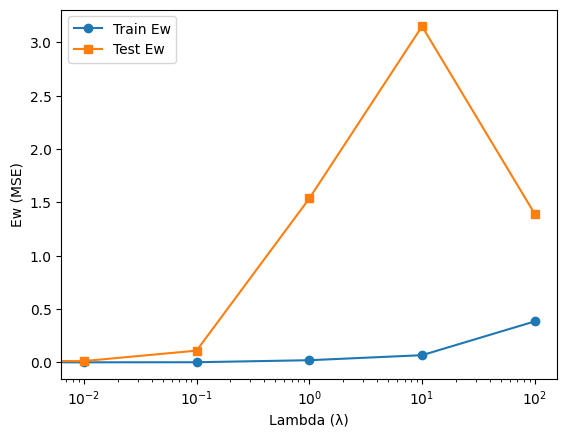

In [4]:
# 80% train, 20% test
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.2,random_state=1)
# Higher-order polynomial
p = PolynomialFeatures(5)
#PolynomialFeatures(8) creates 1, x, x2, x3, x4, x5, x6, x7, x8
Xtr,Xte = p.fit_transform(Xtr),p.transform(Xte)

# Different alpha values, is the regularization strength
L = [0, .01, .1, 1, 10, 100]
#testing 6 different values of alpha: 0-No regularization,0.01-Very weak,0.1  -Weak,1-Moderate,10-Strong,100-  Very strong

train, test = [], []

for l in L:
    m = Ridge(alpha=l)
    #Alpha (α) in Ridge Regression is the regularization strength.
    m.fit(Xtr,ytr)
    train.append(mean_squared_error(ytr,m.predict(Xtr)))
    test.append(mean_squared_error(yte,m.predict(Xte)))

plt.plot(L,train,'o-',label='Train Ew')
plt.plot(L,test,'s-',label='Test Ew')
plt.xscale('log')
plt.xlabel('Lambda (λ)')
plt.ylabel('Ew (MSE)')
plt.legend()
plt.show()